# Has the CTA Frequent Network gained ridership?

**Question.** Between March and December 2025 the CTA phased 20 bus routes into a
"Frequent Network" with 10-minutes-or-better headways. Did those routes gain riders
beyond what they would have gained anyway?

Frequent corridors grew **+1.5pp (weekday), +3.1pp (Saturday), +6.9pp (Sunday)** more than
the rest of the system, after adjusting for seasonality, system-wide trend, and the
pre-existing growth difference between the groups.

Point estimates only — no inference run yet, so none of these are established as
distinguishable from noise.

---

## Sources

**Ridership data**
- [CTA Ridership – Bus Routes – Daily Totals by Route](https://data.cityofchicago.org/Transportation/CTA-Ridership-Bus-Routes-Daily-Totals-by-Route/jyb9-n7fm/about_data)
  (Chicago Data Portal, dataset `jyb9-n7fm`), pulled via the Socrata API:
  `https://data.cityofchicago.org/resource/jyb9-n7fm.csv`.
  Fields: `route`, `date`, `daytype` (**W** = weekday, **A** = Saturday, **U** =
  Sunday/holiday), `rides`. Data here runs through **2026-05-31**.

**Frequent Network definition and rollout**
- [CTA Frequent Network page](https://www.transitchicago.com/frequent/) — program definition:
  10 min or better, 6a–9p weekdays / 9a–9p weekends.
- [Streetsblog Chicago, 2025-03-05](https://chi.streetsblog.org/2025/03/05/10-minute-version-cta-promises-shorter-headways-on-20-bus-routes-there-are-a-bunch-of-reasons-riders-hope-the-plan-will-work-out)
  — the full planned 20-route list split into four seasonal phases. **Primary source for
  the phase assignments below.**
- [CTA: "CTA Launches New Frequent Network for Buses"](https://www.transitchicago.com/cta-launches-new-frequent-network-for-buses/)
  · [Block Club Chicago, 2025-03-03](https://blockclubchicago.org/2025/03/03/cta-promises-10-minutes-or-sooner-buses-on-major-south-west-side-routes-starting-this-month/)
  — phase 1 launched **Sunday, Mar 23, 2025** on 8 South/West Side routes.
- [Mass Transit: "CTA adds four more routes to its short headway Frequent Network"](https://www.masstransitmag.com/bus/press-release/55310386/chicago-transit-authority-cta-cta-adds-four-more-routes-to-its-short-headway-frequent-network)
  — "These additions began service with the network on **Aug. 17** and brought the Frequent
  Network to 16 total routes, with four more planned in December."
- [Chicago Sun-Times, 2025-12-19](https://chicago.suntimes.com/transportation/2025/12/19/cta-bus-transit-frequent-network-routes)
  · [Mass Transit, winter schedule](https://www.masstransitmag.com/bus/news/55339289/chicago-transit-authority-cta-cta-to-reach-2025-frequent-network-expansion-goal-with-winter-schedule-launch)
  — final four (#9, #12, #72, #81) effective **Dec 21, 2025**.

**Confounder: the #53 Pulaski restructure**
- [CTA Board, June 2025 Service Planning presentation (PDF)](https://www.transitchicago.com/assets/1/6/June_2025_-_Service_Planning_-_Board_Presentation_.pdf)
  · [Streetsblog, 2025-06-11](https://chi.streetsblog.org/2025/06/11/at-a-relatively-peaceful-but-productive-meeting-cta-board-approved-bus-route-changes-narcan-machines-track-safety-pilot)
  — the Board extended **#53 Pulaski** south to Ford City and curtailed **#53A**, effective
  **Aug 17, 2025**.

> ⚠️ **One thing to verify.** Sources conflict on whether **#53** and **#20** joined in the
> June or August batch: the March Streetsblog plan puts #53 in summer and #20 in fall,
> while the August press release lists #53 among the August additions. The design below
> excludes **all of Jun–Dec 2025**, so this ambiguity changes nothing.

## Design

The rollout is staggered across four schedule changes, so there is no clean single
"before" and "after." Instead, a **buffered pre/post design**:

| Window | Period | Treatment status |
|---|---|---|
| `PRE`  | Jan–May 2025 | only phase-1 routes treated, and only from Mar 23 |
| *buffer* | Jun–Dec 2025 | **excluded** — rollout in progress |
| `POST` | Jan–May 2026 | all 20 routes fully treated |

Three normalizations, layered:

1. **Seasonality** — compare the *same calendar months* across years, which holds season
   fixed by construction. Also use *average daily rides per day type*, so a window having
   one extra Saturday can't distort anything.
2. **System-wide trend** — a control group of all non-Frequent corridors. You flagged that
   this is tricky, and it is, which is why step 3 exists.
3. **Pre-existing trend** — a **placebo / parallel-trends test** on pre-treatment years.
   CTA picked these routes *because* they were strong, growing corridors, so they were
   already outgrowing the system before any service was added. This step is what separates
   the real effect from the selection effect, and it roughly halves the apparent result.

Plus one unit-of-analysis fix, developed in §2: measure **corridors**, not routes.

In [1]:
import pandas as pd, numpy as np, re, matplotlib.pyplot as plt

# --- validated reference palette (light surface) ---
SURFACE, INK, INK2, MUTED = '#fcfcfb', '#0b0b0b', '#52514e', '#898781'
GRID, AXIS = '#e1e0d9', '#c3c2b7'
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
BLUE_L = '#b7d3f6'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': AXIS, 'axes.labelcolor': INK2, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif', 'font.size': 10, 'figure.dpi': 110,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.titlepad': 10, 'legend.frameon': False,
})

def style(ax, ylab=None, axis='y'):
    ax.grid(axis=axis, zorder=0); ax.set_axisbelow(True); ax.tick_params(length=0)
    if ylab: ax.set_ylabel(ylab, color=INK2)
    return ax

pct = lambda a, b: (b - a) / a * 100

### Load

In [2]:
# Re-download if needed:
# !curl -s "https://data.cityofchicago.org/resource/jyb9-n7fm.csv?\$limit=2000000&\$order=route,date" -o data/cta_bus_daily.csv

d = pd.read_csv('data/cta_bus_daily.csv', dtype={'route': str}, parse_dates=['date'])
d['route'] = d.route.str.strip()
d['year'], d['month'] = d.date.dt.year, d.date.dt.month
print(f"{len(d):,} rows | {d.date.min():%Y-%m-%d} → {d.date.max():%Y-%m-%d} | "
      f"{d.route.nunique()} routes")
d.head()

1,113,495 rows | 2001-01-01 → 2026-05-31 | 188 routes


,route,date,daytype,rides,year,month
0,1,2001-01-02,W,5813,2001,1
1,1,2001-01-03,W,6809,2001,1
2,1,2001-01-04,W,6907,2001,1
3,1,2001-01-05,W,6154,2001,1
4,1,2001-01-08,W,6126,2001,1


In [3]:
FREQ = ['J14','4','9','12','20','34','47','49','53','54',
        '55','60','63','66','72','77','79','81','82','95']

PHASE = {'2025-03-23': ['J14','34','47','54','60','63','79','95'],
         '2025-06-15': ['4','49','66'],
         '2025-08-17': ['20','53','55','77','82'],
         '2025-12-21': ['9','12','72','81']}
phase_of = {r: p for p, rs in PHASE.items() for r in rs}
PHASE_LABEL = {'2025-03-23': 'Mar 2025', '2025-06-15': 'Jun 2025',
               '2025-08-17': 'Aug 2025', '2025-12-21': 'Dec 2025'}
DAYNAME = {'W': 'Weekday', 'A': 'Saturday', 'U': 'Sunday/Holiday'}
YEARS = [2022, 2023, 2024, 2025, 2026]

## 1. Seasonality — why same-month comparison is required

CTA ridership has a strong within-year shape: a January trough, a spring peak, a summer
dip, an October peak. Any before/after that straddles different months would read this
seasonal shape as an effect.

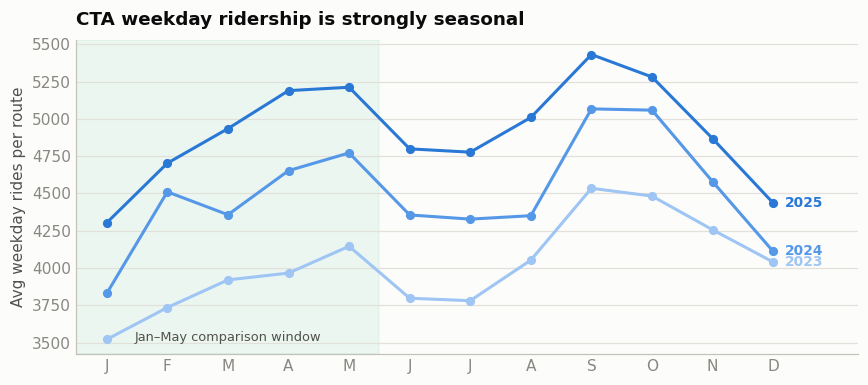

In [4]:
seas = (d[(d.daytype=='W') & d.year.between(2023, 2025)]
        .groupby(['year','month']).rides.mean().unstack(0))
fig, ax = plt.subplots(figsize=(8, 3.6))
for yr, col in zip([2023, 2024, 2025], ['#9ec5f4', '#5598e7', BLUE]):
    ax.plot(seas.index, seas[yr], color=col, lw=2, marker='o', ms=5)
    ax.annotate(str(yr), (12.2, seas[yr].iloc[-1]), color=col, fontweight='bold',
                va='center', fontsize=9)
ax.axvspan(0.5, 5.5, color=AQUA, alpha=0.07, zorder=0)
ax.annotate('Jan–May comparison window', (3, ax.get_ylim()[0]), color=INK2, fontsize=8.5,
            ha='center', va='bottom', xytext=(0, 6), textcoords='offset points')
ax.set_xticks(range(1, 13)); ax.set_xlim(0.5, 13.4)
ax.set_xticklabels(list('JFMAMJJASOND'))
style(ax, 'Avg weekday rides per route')
ax.set_title('CTA weekday ridership is strongly seasonal')
plt.tight_layout(); plt.show()

## 2. Structural screen — finding #53-style problems systematically

Before measuring anything, screen every Frequent route for **structural changes that move
riders between routes** rather than creating new ones. The mechanism to worry about: a
route has express or branch siblings (`X49`, `49B`, `53A`), and either a restructure or the
new frequent local pulls riders off the sibling. The trunk route then posts a big gain that
is really a transfer.

The test: compare each route's growth **alone** vs. its whole **corridor** (route + all
siblings). A large divergence is a red flag.

In [5]:
allr = set(d.route.unique())

def siblings(r):
    base = r[1:] if r.startswith('J') else r
    return sorted(x for x in allr if x != r and
                  (re.fullmatch(rf'{re.escape(base)}[A-Z]+', x) or
                   re.fullmatch(rf'X{re.escape(base)}', x)))

def avg_w(year, routes):
    s = d[(d.year == year) & (d.month <= 5) & (d.daytype == 'W') & d.route.isin(routes)]
    return s.groupby('route').rides.mean().sum()

scr = []
for r in FREQ:
    sb = siblings(r)
    alone = pct(avg_w(2025, [r]), avg_w(2026, [r]))
    corr = pct(avg_w(2025, [r]+sb), avg_w(2026, [r]+sb)) if sb else alone
    scr.append({'route': r, 'siblings': ', '.join(sb) or '—',
                'route alone %': round(alone,1), 'corridor %': round(corr,1),
                'divergence (pp)': round(alone-corr,1),
                'flag': '⚠️' if abs(alone-corr) > 3 else ''})
scr = pd.DataFrame(scr).sort_values('divergence (pp)', ascending=False)
scr

,route,siblings,route alone %,corridor %,divergence (pp),flag
8,53,"53A, 53AL",21.4,2.7,18.7,⚠️
7,49,"49A, 49B, X49",10.7,-0.5,11.2,⚠️
2,9,X9,11.0,6.0,5.0,⚠️
1,4,X4,9.7,8.6,1.1,
9,54,"54A, 54B, X54",-1.3,-2.1,0.8,
12,63,63W,10.6,9.8,0.8,
10,55,"55A, 55N, X55",7.8,7.7,0.1,
13,66,—,-11.5,-11.5,0.0,
18,82,—,5.4,5.4,0.0,
17,81,81W,2.0,2.0,-0.0,


**Three routes flag.** All three are cases where the headline route number overstates
new ridership:

| Route | Alone | Corridor | What happened |
|---|---|---|---|
| **#53 Pulaski** | +21.4% | **+2.7%** | Aug 2025 restructure extended #53 south and curtailed **#53A** — riders transferred, not gained ([CTA Board, June 2025](https://www.transitchicago.com/assets/1/6/June_2025_-_Service_Planning_-_Board_Presentation_.pdf)) |
| **#49 Western** | +10.7% | **−0.5%** | No restructure — the frequent local **cannibalized X49 Western Express and 49B**. Corridor is flat. |
| **#9 Ashland** | +11.0% | **+6.0%** | Same pattern, milder: riders shifted off **X9 Ashland Express** |

The #49 and #9 cases are the more interesting finding: they aren't data artifacts, they're
a **real substitution effect**. When the local runs every 10 minutes, the express advantage
shrinks and riders switch down. That's arguably a service-quality win, but it is *not* new
ridership, and a route-level analysis would score it as one.

Let's look at all three families directly.

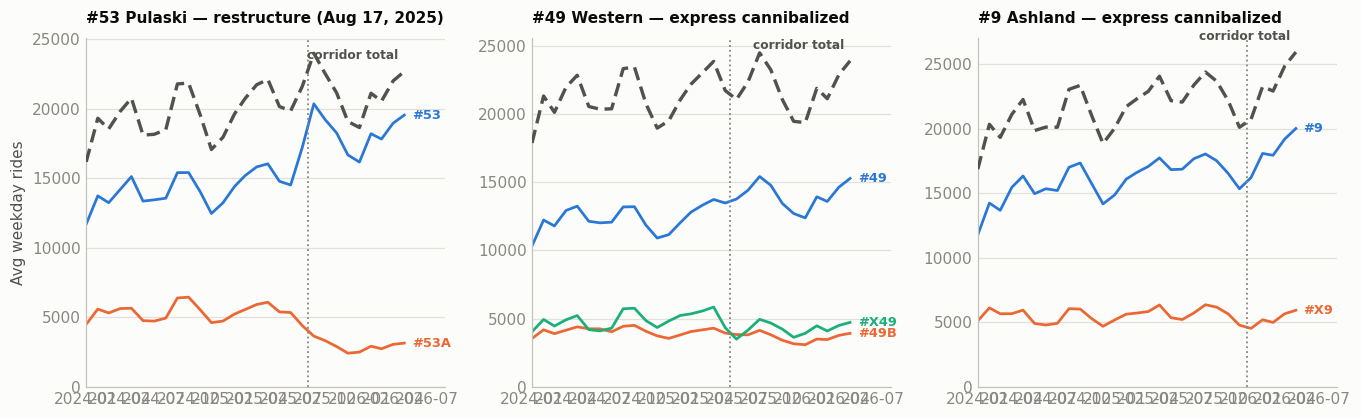

In [6]:
fams = [('#53 Pulaski — restructure (Aug 17, 2025)', ['53','53A'], '2025-08-17'),
        ('#49 Western — express cannibalized', ['49','49B','X49'], '2025-06-15'),
        ('#9 Ashland — express cannibalized', ['9','X9'], '2025-12-21')]
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.9))
for ax, (title, fam, dt) in zip(axes, fams):
    s = d[d.route.isin(fam) & (d.daytype=='W') & (d.date>='2024-01-01')]
    p = s.pivot_table(index=pd.Grouper(key='date', freq='MS'), columns='route',
                      values='rides', aggfunc='mean')
    tot = p.sum(axis=1)
    ax.plot(tot.index, tot, color=INK2, lw=2.2, ls=(0,(4,2)), zorder=5)
    ax.annotate('corridor total', (tot.index[-1], tot.iloc[-1]), color=INK2, fontsize=8,
                fontweight='bold', xytext=(-4, 8), textcoords='offset points', ha='right')
    for col, hue in zip(p.columns, [BLUE, ORANGE, AQUA]):
        ax.plot(p.index, p[col], color=hue, lw=1.8)
        ax.annotate(f'#{col}', (p.index[-1], p[col].iloc[-1]), color=hue, fontsize=8.5,
                    fontweight='bold', xytext=(5, 0), textcoords='offset points',
                    va='center')
    ax.axvline(pd.Timestamp(dt), color=MUTED, lw=1.2, ls=':')
    ax.set_ylim(0, None); ax.set_title(title, fontsize=10)
    ax.set_xlim(p.index[0], p.index[-1] + pd.Timedelta(days=110))
    style(ax)
axes[0].set_ylabel('Avg weekday rides', color=INK2)
plt.tight_layout(); plt.show()

**Decision: analyze corridors, not routes.** Group every route with its express/branch
siblings, for the Frequent set *and* the control group alike, so both sides are measured
the same way. This is the conservative choice — it removes all three transfer effects.

In [7]:
def corridor(r):
    if re.fullmatch(r'X\d+', r): return r[1:]        # X49 -> 49
    m = re.fullmatch(r'(\d+)[A-Z]+', r)              # 53A -> 53, 95W -> 95
    return m.group(1) if m else r                    # J14, N5, 1001 unchanged

d['corridor'] = d.route.map(corridor)
print('Example groupings:')
for k in ['49','53','9','95','54']:
    print(f"  {k:>4}: {sorted(d.loc[d.corridor==k,'route'].unique())}")

Example groupings:
    49: ['49', '49A', '49B', 'X49']
    53: ['53', '53A', '53AL']
     9: ['9', 'X9']
    95: ['95', '95E', '95W']
    54: ['54', '54A', '54B', 'X54']


### Build the corridor panel and the control group

In [8]:
def panel(y, months=(1,2,3,4,5)):
    """Avg daily rides per corridor x daytype. Sum route means within a corridor,
    so a corridor is the whole set of services on that street."""
    s = d[(d.year == y) & (d.month.isin(months))]
    return (s.groupby(['corridor','route','daytype']).rides.mean()
             .groupby(['corridor','daytype']).sum().unstack())

P = {y: panel(y) for y in YEARS}
common = set.intersection(*(set(p.index) for p in P.values()))
keep = sorted(r for r in common if P[2025].loc[r, 'W'] >= 500)   # drop tiny corridors
F = [r for r in keep if r in FREQ]
C = [r for r in keep if r not in FREQ]
print(f"Frequent corridors: {len(F)}   Control corridors: {len(C)}")
print("Missing from Frequent set:", [r for r in FREQ if r not in F] or "none")

Frequent corridors: 20   Control corridors: 81
Missing from Frequent set: none


## 3. The naive picture

Indexed to Jan–May 2022 = 100, so both groups start together and the question is whether
they diverge **at the rollout**.

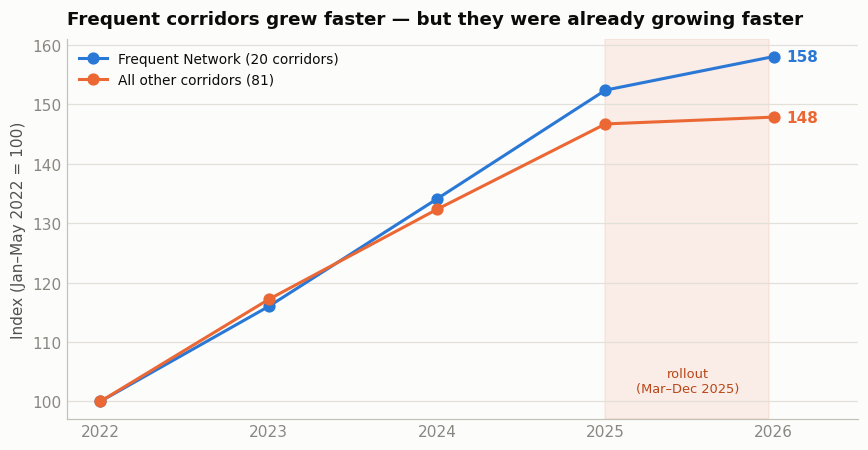

In [9]:
nF = [P[y].loc[F,'W'].sum() for y in YEARS]; nF = [v/nF[0]*100 for v in nF]
nC = [P[y].loc[C,'W'].sum() for y in YEARS]; nC = [v/nC[0]*100 for v in nC]

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.axvspan(2025, 2025.97, color=ORANGE, alpha=0.10, zorder=0)
ax.annotate('rollout\n(Mar–Dec 2025)', (2025.49, 101), color='#b8471a', fontsize=8.5,
            ha='center', va='bottom')
ax.plot(YEARS, nF, color=BLUE, lw=2, marker='o', ms=7, label='Frequent Network (20 corridors)')
ax.plot(YEARS, nC, color=ORANGE, lw=2, marker='o', ms=7, label=f'All other corridors ({len(C)})')
for v, col in [(nF[-1], BLUE), (nC[-1], ORANGE)]:
    ax.annotate(f'{v:.0f}', (YEARS[-1], v), color=col, fontweight='bold', fontsize=10,
                xytext=(8, 0), textcoords='offset points', va='center')
ax.set_xticks(YEARS); ax.set_xlim(2021.8, 2026.5)
style(ax, 'Index (Jan–May 2022 = 100)')
ax.set_title('Frequent corridors grew faster — but they were already growing faster')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()

Blue ends above orange — but it was already pulling away **before** the orange band.
That is exactly the trap you flagged with system-wide normalization. Quantify it next.

## 4. Parallel-trends test — the step that matters

A difference-in-differences is only valid if the groups were on parallel paths beforehand.
Run the identical Jan–May comparison on **pre-treatment** year pairs as a placebo. If the
gap is already positive before the rollout, the naive DiD is crediting selection to service.

In [10]:
rows = []
for dt in ['W','A','U']:
    for a, b in zip(YEARS, YEARS[1:]):
        f = pct(P[a].loc[F,dt].sum(), P[b].loc[F,dt].sum())
        cc = pct(P[a].loc[C,dt].sum(), P[b].loc[C,dt].sum())
        rows.append({'Day type': DAYNAME[dt], 'Period': f'{a}→{b}',
                     'Frequent %': round(f,1), 'Control %': round(cc,1),
                     'Gap (pp)': round(f-cc,1),
                     'Status': 'POST' if b == 2026 else 'pre'})
pt = pd.DataFrame(rows)
pt.pivot(index='Period', columns='Day type', values='Gap (pp)')[
    ['Weekday','Saturday','Sunday/Holiday']]

Day type,Weekday,Saturday,Sunday/Holiday
Period,,,
2022→2023,-1.2,1.3,0.9
2023→2024,2.7,2.5,3.6
2024→2025,2.8,1.6,1.7
2025→2026,2.9,4.9,9.0


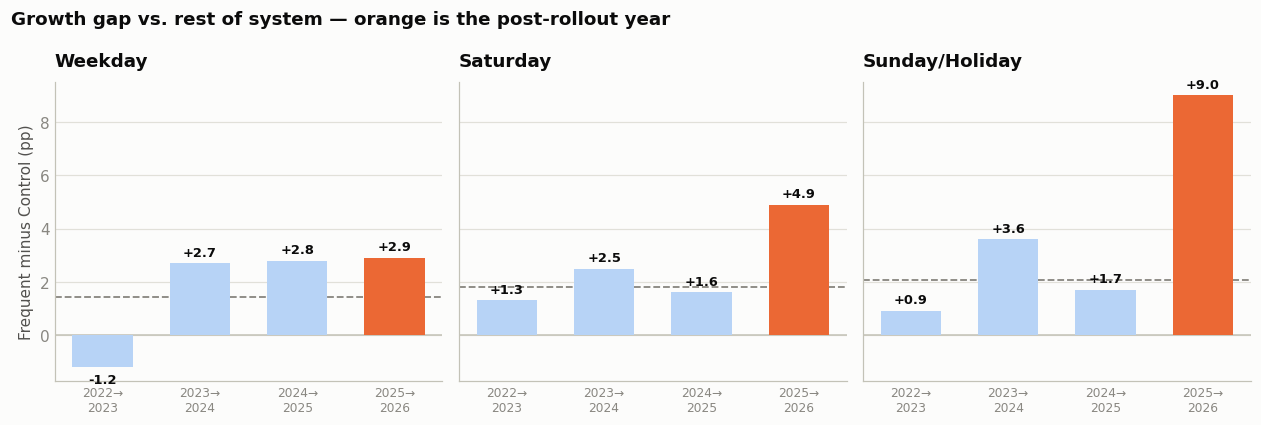

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.9), sharey=True)
for ax, dt in zip(axes, ['W','A','U']):
    s = pt[pt['Day type'] == DAYNAME[dt]].reset_index(drop=True)
    ax.bar(range(len(s)), s['Gap (pp)'], width=0.62, zorder=3,
           color=[BLUE_L if st=='pre' else ORANGE for st in s['Status']])
    pre = s.loc[s.Status=='pre','Gap (pp)'].mean()
    ax.axhline(pre, color=MUTED, ls='--', lw=1.2, zorder=2)
    ax.annotate(f'pre-trend avg {pre:+.1f}', (len(s)-0.45, pre), color=INK2, fontsize=8,
                ha='right', va='bottom', xytext=(0,3), textcoords='offset points')
    for i, v in enumerate(s['Gap (pp)']):
        ax.annotate(f'{v:+.1f}', (i, v), ha='center', fontsize=8.5, color=INK,
                    fontweight='bold', va='bottom' if v>=0 else 'top',
                    xytext=(0, 3 if v>=0 else -4), textcoords='offset points')
    ax.axhline(0, color=AXIS, lw=1)
    ax.set_xticks(range(len(s)))
    ax.set_xticklabels([p.replace('→','→\n') for p in s['Period']], fontsize=8)
    ax.set_title(DAYNAME[dt]); style(ax)
axes[0].set_ylabel('Frequent minus Control (pp)', color=INK2)
fig.suptitle('Growth gap vs. rest of system — orange is the post-rollout year',
             x=0.007, ha='left', fontweight='bold', fontsize=12)
plt.tight_layout(); plt.show()

The gap is non-zero before treatment, so the naive DiD is not clean. Subtracting the
mean pre-trend gives an adjusted point estimate.

In [12]:
adj = []
for dt in ['W','A','U']:
    s = pt[pt['Day type'] == DAYNAME[dt]]
    pre = s.loc[s.Status=='pre','Gap (pp)'].mean()
    post = s.loc[s.Status=='POST','Gap (pp)'].iloc[0]
    adj.append({'Day type': DAYNAME[dt], 'Naive DiD (pp)': round(post,1),
                'Mean pre-trend (pp)': round(pre,1),
                'Adjusted effect (pp)': round(post-pre,1)})
adj = pd.DataFrame(adj).set_index('Day type')
adj

,Naive DiD (pp),Mean pre-trend (pp),Adjusted effect (pp)
Day type,,,
Weekday,2.9,1.4,1.5
Saturday,4.9,1.8,3.1
Sunday/Holiday,9.0,2.1,6.9


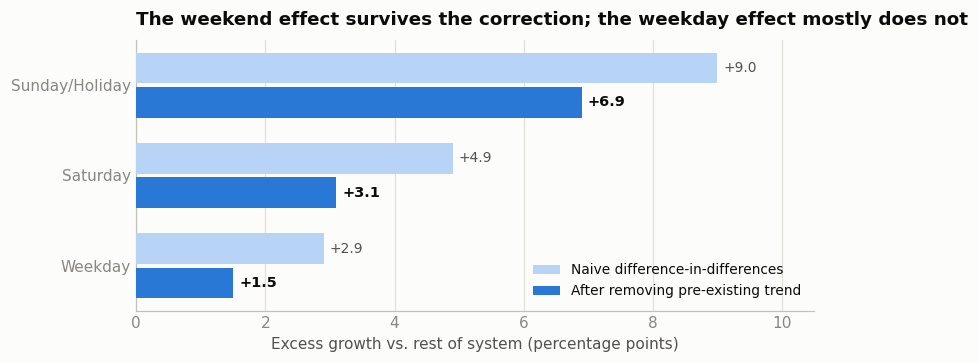

In [13]:
fig, ax = plt.subplots(figsize=(7.6, 3.4))
y = np.arange(len(adj))
ax.barh(y+0.19, adj['Naive DiD (pp)'], height=0.34, color=BLUE_L, zorder=3,
        label='Naive difference-in-differences')
ax.barh(y-0.19, adj['Adjusted effect (pp)'], height=0.34, color=BLUE, zorder=3,
        label='After removing pre-existing trend')
for i, (n_, a_) in enumerate(zip(adj['Naive DiD (pp)'], adj['Adjusted effect (pp)'])):
    ax.annotate(f'{n_:+.1f}', (n_, i+0.19), va='center', fontsize=9, color=INK2,
                xytext=(4,0), textcoords='offset points')
    ax.annotate(f'{a_:+.1f}', (a_, i-0.19), va='center', fontsize=9.5, color=INK,
                fontweight='bold', xytext=(4,0), textcoords='offset points')
ax.set_yticks(y); ax.set_yticklabels(adj.index); ax.set_xlim(0, 10.5)
style(ax, axis='x'); ax.grid(axis='y', visible=False)
ax.set_xlabel('Excess growth vs. rest of system (percentage points)', color=INK2)
ax.set_title('The weekend effect survives the correction; the weekday effect mostly does not')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()

## 5. Corridor-by-corridor detail

Is the aggregate broad-based or driven by a few corridors? These are corridor-level figures,
so #53, #49 and #9 are already corrected.

In [14]:
ctrl_w = pct(P[2025].loc[C,'W'].sum(), P[2026].loc[C,'W'].sum())
per = pd.DataFrame({'corridor': F, 'phase': [PHASE_LABEL[phase_of[r]] for r in F]})
for dt, nm in [('W','wkdy'), ('A','sat'), ('U','sun')]:
    per[f'{nm} %'] = [round(pct(P[2025].loc[r,dt], P[2026].loc[r,dt]),1) for r in F]
per['wkdy riders 2026'] = [round(P[2026].loc[r,'W']) for r in F]
per['wkdy vs ctrl (pp)'] = (per['wkdy %'] - ctrl_w).round(1)
per = per.sort_values('wkdy %', ascending=False).reset_index(drop=True)
print(f'Control-group weekday change, Jan–May 25→26: {ctrl_w:+.1f}%')
per

Control-group weekday change, Jan–May 25→26: +0.8%


,corridor,phase,wkdy %,sat %,sun %,wkdy riders 2026,wkdy vs ctrl (pp)
0,60,Mar 2025,12.6,12.7,18.6,11578,11.8
1,47,Mar 2025,10.1,3.2,15.2,9375,9.3
2,63,Mar 2025,9.8,7.7,15.1,14390,9.0
3,4,Jun 2025,8.6,4.7,24.3,17277,7.8
4,55,Aug 2025,7.7,12.5,15.2,8279,6.9
5,20,Aug 2025,7.7,2.6,25.6,14224,6.9
6,95,Mar 2025,6.8,2.7,7.9,4968,6.0
7,9,Dec 2025,6.0,3.5,7.3,23525,5.2
8,77,Aug 2025,5.7,7.7,18.8,14856,4.9
9,82,Aug 2025,5.4,10.8,20.0,13820,4.6


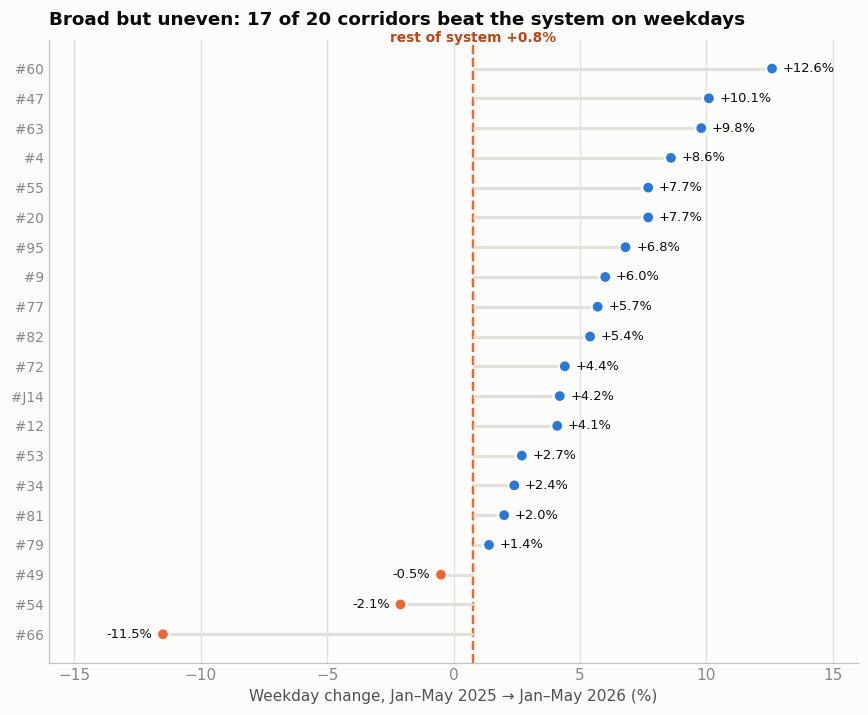

In [15]:
p = per.sort_values('wkdy %')
fig, ax = plt.subplots(figsize=(8, 6.6))
y = np.arange(len(p))
ax.axvline(ctrl_w, color=ORANGE, lw=1.6, ls='--', zorder=2)
ax.annotate(f'rest of system {ctrl_w:+.1f}%', (ctrl_w, len(p)-0.2), color='#b8471a',
            fontsize=9, ha='center', va='bottom', fontweight='bold')
ax.hlines(y, ctrl_w, p['wkdy %'], color=GRID, lw=2, zorder=2)
ax.scatter(p['wkdy %'], y, s=64, zorder=4, edgecolor=SURFACE, linewidth=1.6,
           color=[BLUE if v >= ctrl_w else ORANGE for v in p['wkdy %']])
for i, v in enumerate(p['wkdy %']):
    ax.annotate(f'{v:+.1f}%', (v, i), fontsize=8.5, color=INK, va='center',
                ha='left' if v >= ctrl_w else 'right',
                xytext=(7 if v >= ctrl_w else -7, 0), textcoords='offset points')
ax.set_yticks(y); ax.set_yticklabels([f'#{r}' for r in p['corridor']], fontsize=9)
ax.set_xlim(-16, 16)
style(ax, axis='x'); ax.grid(axis='y', visible=False)
ax.set_xlabel('Weekday change, Jan–May 2025 → Jan–May 2026 (%)', color=INK2)
n_beat = (per['wkdy %'] > ctrl_w).sum()
ax.set_title(f'Broad but uneven: {n_beat} of 20 corridors beat the system on weekdays')
plt.tight_layout(); plt.show()

## 6. Dose-response: Sunday vs weekday

CTA's own press releases describe the *largest* service increases on Sundays — 25–60% more
Sunday service on several routes, versus ~10–15% on weekdays
([Sun-Times](https://chicago.suntimes.com/transportation/2025/12/19/cta-bus-transit-frequent-network-routes),
[Mass Transit](https://www.masstransitmag.com/bus/press-release/55310386/chicago-transit-authority-cta-cta-adds-four-more-routes-to-its-short-headway-frequent-network)).

If added service is actually causing the ridership, Sunday gains should systematically
exceed weekday gains. **This is the strongest causal evidence in the notebook** — it's a
dose-response pattern, and selection effects don't predict it.

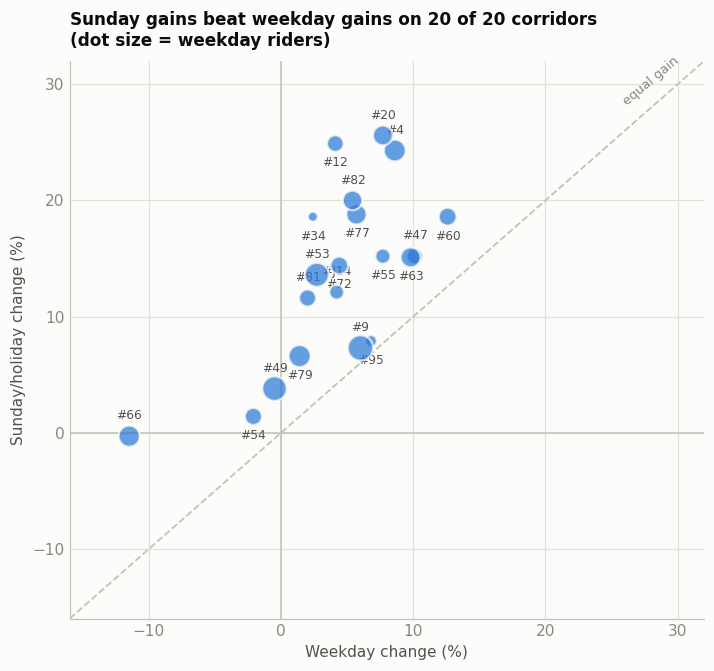

Median Sunday gain +14.8%  vs  median weekday gain +4.9%


In [16]:
fig, ax = plt.subplots(figsize=(6.6, 6.2))
lim = (-16, 32)
ax.plot(lim, lim, color=AXIS, lw=1.2, ls='--', zorder=2)
ax.annotate('equal gain', (28, 28), color=MUTED, fontsize=8.5, rotation=40,
            ha='center', va='bottom')
ax.scatter(per['wkdy %'], per['sun %'], s=[v/85 for v in per['wkdy riders 2026']],
           color=BLUE, alpha=0.72, edgecolor=SURFACE, linewidth=1.5, zorder=4)
# crude collision avoidance: alternate label above/below by x-order
for k, (_, r) in enumerate(per.sort_values('wkdy %').iterrows()):
    dy = 11 if k % 2 == 0 else -15
    ax.annotate(f"#{r['corridor']}", (r['wkdy %'], r['sun %']), fontsize=8, color=INK2,
                xytext=(0, dy), textcoords='offset points', ha='center')
ax.axhline(0, color=AXIS, lw=1); ax.axvline(0, color=AXIS, lw=1)
ax.set_xlim(*lim); ax.set_ylim(*lim)
style(ax, 'Sunday/holiday change (%)'); ax.grid(axis='x')
ax.set_xlabel('Weekday change (%)', color=INK2)
n = (per['sun %'] > per['wkdy %']).sum()
ax.set_title(f'Sunday gains beat weekday gains on {n} of 20 corridors\n'
             '(dot size = weekday riders)', fontsize=11)
plt.tight_layout(); plt.show()
print(f"Median Sunday gain {per['sun %'].median():+.1f}%  vs  "
      f"median weekday gain {per['wkdy %'].median():+.1f}%")

## 7. Visual check: every corridor, month by month

Look for anything the automated screen missed — level shifts unrelated to the rollout,
suspicious flatlines, reporting gaps. The dotted line marks each corridor's rollout date;
the shaded band is the excluded buffer.

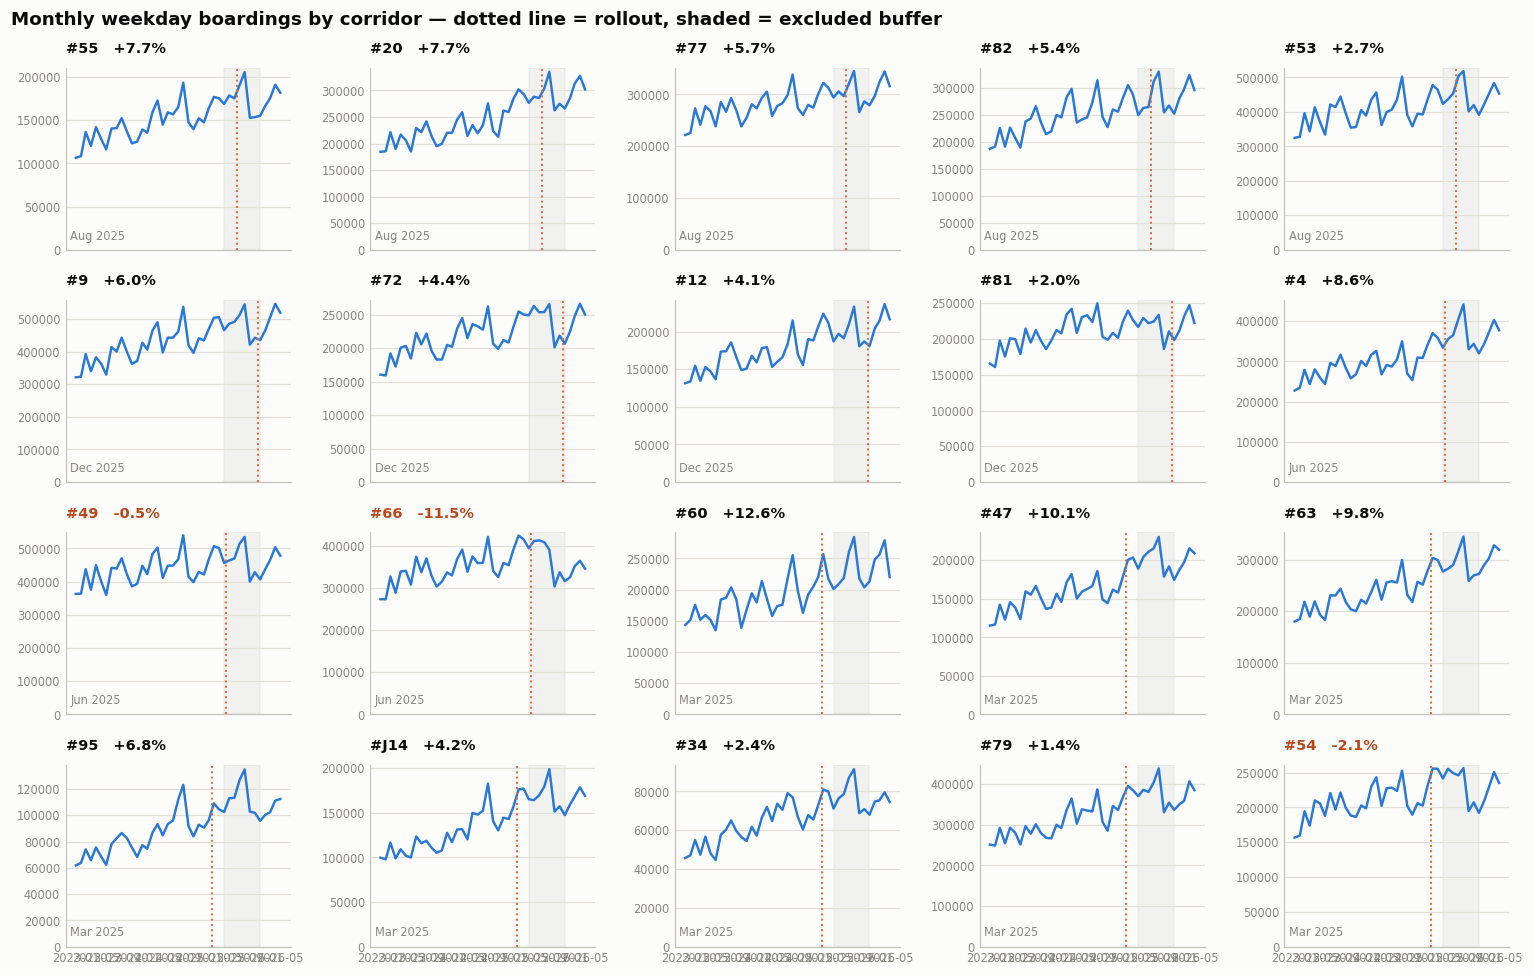

In [17]:
mon = (d[d.daytype=='W'].groupby(['corridor', pd.Grouper(key='date', freq='MS')])
       .rides.sum().unstack(0))
mon = mon.loc['2023-01-01':]
order = list(per.sort_values(['phase','wkdy %'], ascending=[True,False])['corridor'])

fig, axes = plt.subplots(4, 5, figsize=(14, 9), sharex=True)
for ax, r in zip(axes.ravel(), order):
    ax.axvspan(pd.Timestamp('2025-06-01'), pd.Timestamp('2025-12-31'),
               color=MUTED, alpha=0.09, zorder=0)
    ax.plot(mon.index, mon[r], color=BLUE, lw=1.6, zorder=3)
    ax.axvline(pd.Timestamp(phase_of[r]), color=ORANGE, lw=1.3, ls=':', zorder=4)
    chg = per.loc[per.corridor==r, 'wkdy %'].iloc[0]
    ax.set_title(f'#{r}   {chg:+.1f}%', fontsize=9.5,
                 color=INK if chg >= ctrl_w else '#b8471a')
    ax.annotate(PHASE_LABEL[phase_of[r]], (0.02, 0.06), xycoords='axes fraction',
                fontsize=7.5, color=MUTED)
    ax.set_ylim(0, None); ax.tick_params(labelsize=7.5, length=0)
    ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)
fig.suptitle('Monthly weekday boardings by corridor — dotted line = rollout, '
             'shaded = excluded buffer',
             x=0.007, ha='left', fontweight='bold', fontsize=12)
plt.tight_layout(); plt.show()

**#66 Chicago is the one clear outlier** — it *declined* ~11% despite joining the
network, and the small-multiple shows the drop starting around Oct 2025 rather than at its
June rollout. That timing argues for an external cause (construction, a reroute, or a
corridor-specific shift) rather than the service change. Worth a separate look; it drags
the aggregate down.

## 8. Robustness: the phase-1 cohort over a longer horizon

The 8 routes treated in March 2025 have the longest post period. Using **Jun–Dec** windows
gives a full pre year (2024) and a full post year (2025) — an independent check that
reuses none of the Jan–May design.

In [18]:
jd = {y: panel(y, months=(6,7,8,9,10,11,12)) for y in [2023, 2024, 2025]}
ph1 = [r for r in PHASE['2025-03-23'] if all(r in jd[y].index for y in jd)]
cix = [r for r in C if all(r in jd[y].index for y in jd)]
out = []
for lab, idx in [(f'Phase-1 Frequent ({len(ph1)})', ph1), (f'Control ({len(cix)})', cix)]:
    v = [jd[y].loc[idx,'W'].sum() for y in [2023, 2024, 2025]]
    out.append({'Group': lab, '2023': round(v[0]), '2024': round(v[1]), '2025': round(v[2]),
                '23→24 (pre) %': round(pct(v[0],v[1]),1),
                '24→25 (post) %': round(pct(v[1],v[2]),1)})
out = pd.DataFrame(out)
out['gap vs control (pp)'] = (out['24→25 (post) %'] - out['24→25 (post) %'].iloc[-1]).round(1)
out

,Group,2023,2024,2025,23→24 (pre) %,24→25 (post) %,gap vs control (pp)
0,Phase-1 Frequent (8),59423,69006,79819,16.1,15.7,7.7
1,Control (81),305139,331472,357851,8.6,8.0,0.0


## 9. Inference

Everything above is point estimates. This section attaches uncertainty.

**Statistic.** For each corridor, take log-growth between consecutive Jan–May windows.
Subtract the corridor's own mean pre-period growth (22→23, 23→24, 24→25) from its post
growth (25→26). That deviation is how much a corridor's last-year growth departed from its
own recent trend. The effect is the mean deviation of Frequent corridors minus the mean
deviation of control corridors.

**Two tests, both standard:**
- **Permutation test** — randomly relabel which 20 of the ~100 corridors are "Frequent",
  recompute the statistic 20,000 times, and see how often chance produces something at
  least as large. Appropriate here because there are only 20 treated units.
- **Bootstrap** — resample corridors with replacement within each group, 20,000 times, for a
  95% confidence interval.

Corridors that don't run on a given day type are dropped from that day type's test. Each
corridor counts equally (unweighted), so this is not identical to the ridership-weighted
aggregates in §4 — both are reported below.

In [19]:
from scipy import stats
rng = np.random.default_rng(0)

def devs(dt):
    ok = [r for r in keep
          if all(np.isfinite(P[y].loc[r,dt]) and P[y].loc[r,dt] > 0 for y in YEARS)]
    g = {b: np.log(P[b].loc[ok,dt].values / P[a].loc[ok,dt].values)
         for a, b in zip(YEARS, YEARS[1:])}
    pre = np.mean([g[y] for y in YEARS[1:-1]], axis=0)
    return pd.Series(g[YEARS[-1]] - pre, index=ok)

NREP = 20000
inf = []
for dt in ['W','A','U']:
    v = devs(dt)
    f = v[[r for r in F if r in v.index]].values
    c = v[[r for r in C if r in v.index]].values
    D = (f.mean() - c.mean()) * 100

    pool = np.concatenate([f, c]); n = len(f)
    null = np.empty(NREP)
    for i in range(NREP):                      # one shuffle, split into the two groups
        sh = rng.permutation(pool)
        null[i] = (sh[:n].mean() - sh[n:].mean()) * 100
    p_perm = (np.abs(null) >= abs(D)).mean()

    bs = np.array([rng.choice(f, n, True).mean() - rng.choice(c, len(c), True).mean()
                   for _ in range(NREP)]) * 100
    lo, hi = np.percentile(bs, [2.5, 97.5])

    inf.append({'Day type': DAYNAME[dt], 'n freq': n, 'n ctrl': len(c),
                'Effect (pp)': round(D,1), 'CI low': round(lo,1), 'CI high': round(hi,1),
                'Permutation p': round(p_perm,4),
                "Welch t p": round(stats.ttest_ind(f, c, equal_var=False).pvalue,4)})
inf = pd.DataFrame(inf).set_index('Day type')
inf

,n freq,n ctrl,Effect (pp),CI low,CI high,Permutation p,Welch t p
Day type,,,,,,,
Weekday,20,81,2.6,-0.7,5.8,0.2593,0.1178
Saturday,20,60,2.6,-1.6,6.8,0.3150,0.2316
Sunday/Holiday,20,56,7.1,2.8,11.3,0.0047,0.0028


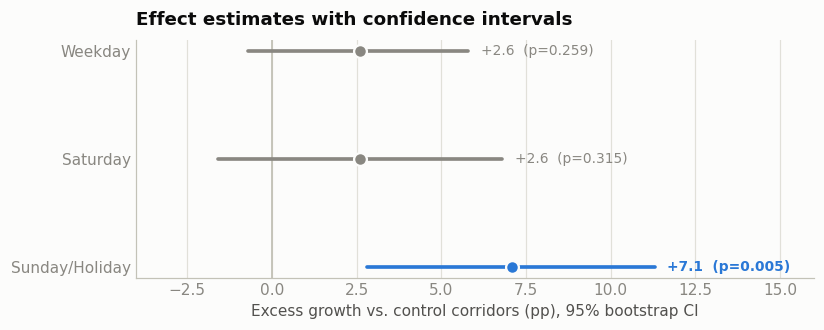

In [20]:
fig, ax = plt.subplots(figsize=(7.6, 3.1))
y = np.arange(len(inf))[::-1]
ax.axvline(0, color=AXIS, lw=1.2, zorder=2)
for yi, (_, r) in zip(y, inf.iterrows()):
    sig = r['Permutation p'] < 0.05
    col = BLUE if sig else MUTED
    ax.plot([r['CI low'], r['CI high']], [yi, yi], color=col, lw=2.4,
            solid_capstyle='round', zorder=3)
    ax.scatter([r['Effect (pp)']], [yi], s=70, color=col, zorder=4,
               edgecolor=SURFACE, linewidth=1.5)
    ax.annotate(f"{r['Effect (pp)']:+.1f}  (p={r['Permutation p']:.3f})",
                (r['CI high'], yi), color=col, fontsize=9,
                fontweight='bold' if sig else 'normal',
                xytext=(8, 0), textcoords='offset points', va='center')
ax.set_yticks(y); ax.set_yticklabels(inf.index)
ax.set_xlim(-4, 16); style(ax, axis='x'); ax.grid(axis='y', visible=False)
ax.set_xlabel('Excess growth vs. control corridors (pp), 95% bootstrap CI', color=INK2)
ax.set_title('Effect estimates with confidence intervals')
plt.tight_layout(); plt.show()

### Dose-response check

CTA added more Sunday service than weekday service. Within each Frequent corridor, compare
its Sunday deviation to its weekday deviation — a paired, within-corridor test that needs no
control group. The same contrast among control corridors is the placebo.

In [21]:
dw, du = devs('W'), devs('U')
fi = [r for r in F if r in dw.index and r in du.index]
ci = [r for r in C if r in dw.index and r in du.index]
w, u = dw[fi].values, du[fi].values
wc, uc = dw[ci].values, du[ci].values

dose = pd.DataFrame([
    {'Group': f'Frequent (n={len(fi)})', 'Mean Sun−Wkdy (pp)': round(np.mean(u-w)*100,1),
     'Positive': f'{(u>w).sum()}/{len(fi)}',
     'Wilcoxon p': round(stats.wilcoxon(u, w).pvalue,5),
     'Paired t p': round(stats.ttest_rel(u, w).pvalue,5)},
    {'Group': f'Control (n={len(ci)}) — placebo', 'Mean Sun−Wkdy (pp)': round(np.mean(uc-wc)*100,1),
     'Positive': f'{(uc>wc).sum()}/{len(ci)}',
     'Wilcoxon p': round(stats.wilcoxon(uc, wc).pvalue,5),
     'Paired t p': round(stats.ttest_rel(uc, wc).pvalue,5)},
]).set_index('Group')
dose

,Mean Sun−Wkdy (pp),Positive,Wilcoxon p,Paired t p
Group,,,,
Frequent (n=20),5.0,17/20,0.00102,0.00086
Control (n=56) — placebo,0.5,28/56,0.88327,0.66909


## Results

| Day type | Effect | 95% CI | Permutation p |
|---|---|---|---|
| Weekday | +2.6pp | −0.7 to +5.8 | 0.26 |
| Saturday | +2.6pp | −1.6 to +6.8 | 0.32 |
| Sunday/Holiday | **+7.1pp** | +2.8 to +11.3 | **0.005** |

Sunday separates from zero; weekday and Saturday do not. The dose-response contrast
(Sunday minus weekday, within corridor) is +5.0pp, p≈0.001, versus +0.5pp, p=0.88 in the
control placebo.

Ridership-weighted aggregates (§4) give +1.5 / +3.1 / +6.9pp — same ordering, and the
Sunday figure is close either way.

### Confounders — tested vs. not

**Handled:**
- Seasonality — same calendar months throughout.
- System-wide trend — control group of non-Frequent corridors.
- Pre-existing group growth difference — subtracted per corridor.
- Rider transfers between related routes — corridor aggregation (§2), which changes the
  weekday estimate by roughly 2×.
- Rollout-date uncertainty for #53/#20 — Jun–Dec 2025 excluded entirely.

**Not tested — these could still move the result:**
- **Service shifted away from control routes.** If non-Frequent routes lost service hours as
  resources moved to Frequent routes, the control group is depressed and the gap is
  inflated. Needs CTA scheduled-service data (GTFS archives). This is the largest untested
  threat.
- **Route selection.** CTA chose these corridors for growing demand; the pre-trend
  adjustment assumes that trend would have continued linearly, which is an assumption, not
  a measurement.
- **#66 Chicago** declined ~11%; its drop begins months after its rollout (§7). Cause
  unknown. Not excluded from any figure above.
- **Pre-period contamination.** Jan–May 2025 includes ~2 months of phase-1 treatment, which
  biases the estimate downward.
- **Geography.** Frequent routes are disproportionately South/West Side; no test for
  differential neighborhood-level trends.
- **Boardings, not trips.** Transfers between two Frequent routes count twice.
- **Post period is 5 months**, and only 5 months for the December cohort.